In [1]:
# 1. Make sure internet is ON for this notebook (Settings panel on the right → Internet → On)

# 2. Auto-accept the MS EULA and install the font package
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get update -qq
!apt-get install -y ttf-mscorefonts-installer -qq

# 3. Rebuild matplotlib's font cache so it picks up the new font
import matplotlib.font_manager as fm
import subprocess

# find the installed Georgia files and register them directly
georgia_paths = subprocess.run(["fc-list", ":family=Georgia"], capture_output=True, text=True).stdout
print(georgia_paths)

for line in georgia_paths.strip().split("\n"):
    if line:
        path = line.split(":")[0]
        fm.fontManager.addfont(path)

# 4. Confirm it's available
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Georgia'
print("Georgia" in {f.name for f in fm.fontManager.ttflist})

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package libmspack0:amd64.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../00-libmspack0_0.10.1-2build2_amd64.deb ...
Unpacking libmspack0:amd64 (0.10.1-2build2) ...
Selecting previously unselected package cabextract.
Preparing to unpack .../01-cabextract_1.9-3_amd64.deb ...
Unpacking cabextract (1.9-3) ...
Selecting previously unselected package xfonts-encodings.
Preparing to unpack .../02-xfonts-encodings_1%3a1.0.5-0ubuntu2_all.deb ...
Unpacking xfonts-encodings (1:1.0.5-0ubuntu2) ...
Selecting previously unselected package xfonts-utils.
Preparing to unpack .../03-xfonts-utils_1%3a7.7+6build2_amd64.deb ...
Unpacking xfonts-utils (1:7.7+6build2) ...
Selecting previously unselected package pyth

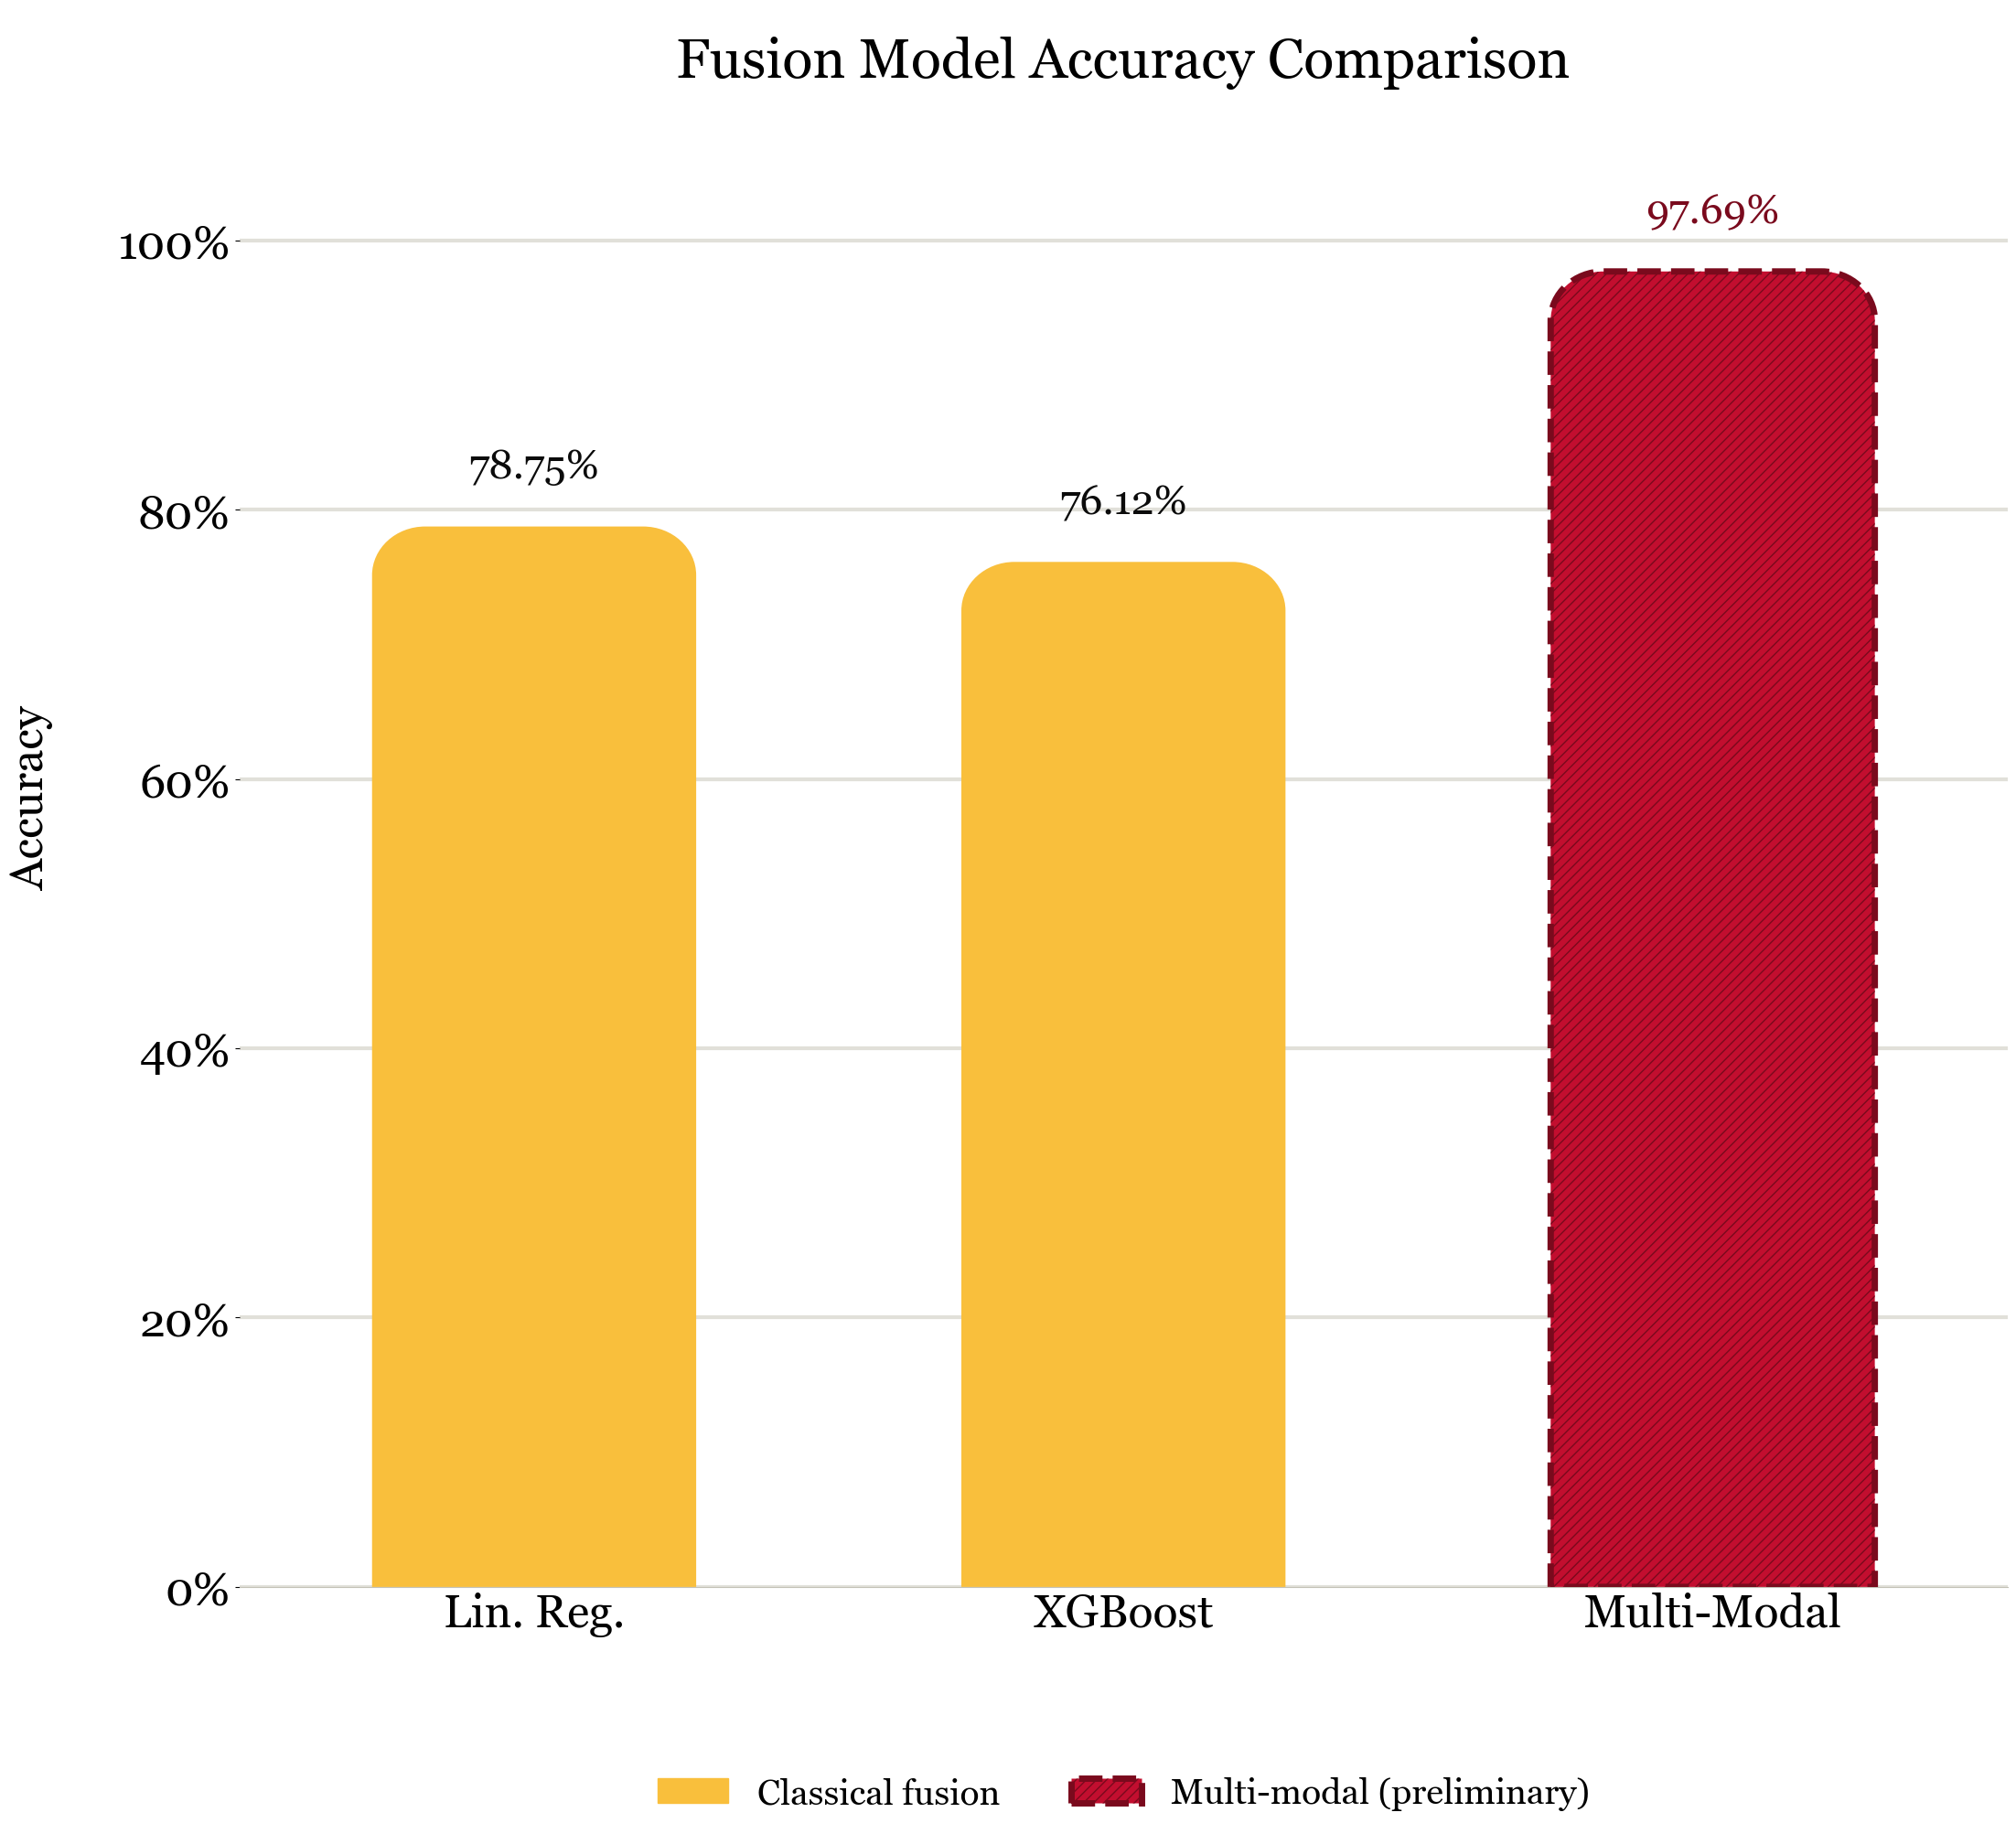

In [22]:
# """
# Fusion model accuracy comparison — vertical bar chart with rounded top corners.
# Runs on Kaggle with Internet OFF — uses matplotlib's built-in DejaVu Sans,
# no apt-get / font install required.
 
# Multi-Modal is a PLACEHOLDER value (model not yet trained) and is marked
# visually as preliminary — hatched fill + dashed edge + label — so it can't
# be mistaken for a finished result.
# """
 
# import matplotlib.pyplot as plt
# import matplotlib.path as mpath
# import matplotlib.patches as mpatches
# from matplotlib.ticker import PercentFormatter
 
# # ── data ──────────────────────────────────────────────────────────
# accuracies = {
#     "Lin. Reg.":   0.7875,
#     "XGBoost":     0.7612,
#     "Multi-Modal": 0.9974,   # placeholder — training not yet complete
# }
 
# preliminary = {"Multi-Modal"}
 
# colors = {
#     "Lin. Reg.":   "#f9bf3c",
#     "XGBoost":     "#f9bf3c",
#     "Multi-Modal": "#c20e2f",
# }
 
# labels = list(accuracies.keys())
# values = [v * 100 for v in accuracies.values()]
# bar_colors = [colors[label] for label in labels]
 
# # ── plot ──────────────────────────────────────────────────────────
# # Scaled to a multiple of 6.04 x 5.91 (multiplied by 2 for larger output)
# fig, ax = plt.subplots(figsize=(12.08, 11.82))
 
# x_pos = list(range(len(labels)))
# bar_width = 0.55
# max_val = max(values)
 
# # Set limits BEFORE drawing so we can calculate the aspect ratio for round corners
# ax.set_xlim(-0.5, len(labels) - 0.5)
# ax.set_ylim(0, max_val * 1.2)
 
# # Force the canvas to draw so we can get accurate pixel dimensions
# fig.canvas.draw()
 
# # Calculate the physical data ratio to keep the rounded corners perfectly circular
# bbox = ax.get_window_extent()
# x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
# y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
# px_per_x = bbox.width / x_range
# px_per_y = bbox.height / y_range
# aspect_ratio = px_per_x / px_per_y  # how many Y data-units equal one X data-unit visually
 
 
# def rounded_bar(ax, x, height, width, color, radius_x=0.09,
#                 hatch=None, edgecolor=None, linewidth=0, linestyle="-"):
#     """Draws a vertical bar rounding the top-left and top-right corners
#     using exact Bezier paths, matching the reference notebook's technique."""
 
#     # Scale the Y radius so it physically matches the X radius in pixels
#     radius_y = radius_x * aspect_ratio
 
#     # Cap the rounding if the bar happens to be extremely short
#     if radius_y > height:
#         radius_y = height
 
#     left = x - width / 2
#     right = x + width / 2
#     bottom = 0
#     top = height
 
#     kappa = 0.552284749831
 
#     path_data = [
#         (mpath.Path.MOVETO,  [left, bottom]),
#         (mpath.Path.LINETO,  [left, top - radius_y]),
#         # top-left corner arc
#         (mpath.Path.CURVE4,  [left, top - radius_y * (1 - kappa)]),
#         (mpath.Path.CURVE4,  [left + radius_x * (1 - kappa), top]),
#         (mpath.Path.LINETO,  [left + radius_x, top]),
#         # top edge to right
#         (mpath.Path.LINETO,  [right - radius_x, top]),
#         # top-right corner arc
#         (mpath.Path.CURVE4,  [right - radius_x * (1 - kappa), top]),
#         (mpath.Path.CURVE4,  [right, top - radius_y * (1 - kappa)]),
#         (mpath.Path.LINETO,  [right, top - radius_y]),
#         (mpath.Path.LINETO,  [right, bottom]),
#         (mpath.Path.CLOSEPOLY, [left, bottom]),
#     ]
 
#     codes, verts = zip(*path_data)
#     path = mpath.Path(verts, codes)
#     patch = mpatches.PathPatch(
#         path, facecolor=color, edgecolor=edgecolor or color,
#         linewidth=linewidth, linestyle=linestyle, hatch=hatch,
#         clip_on=True, zorder=3,
#     )
#     ax.add_patch(patch)
#     return patch
 
 
# # draw bars + labels
# for x, label, val, color in zip(x_pos, labels, values, bar_colors):
#     is_prelim = label in preliminary
#     rounded_bar(
#         ax, x, val, bar_width, color,
#         radius_x=0.09,
#         hatch="///" if is_prelim else None,
#         edgecolor="#7a0a1d" if is_prelim else color,
#         linewidth=2.5 if is_prelim else 0,  # Scaled up line width
#         linestyle="--" if is_prelim else "-",
#     )
 
#     ax.text(
#         x, val + max_val * 0.03,
#         f"{val:.2f}%",
#         va="bottom", ha="center",
#         fontsize=16, fontweight="medium", # Scaled up font
#         color="#7a0a1d" if is_prelim else "#0b0b0b",
#     )
#     # if is_prelim:
#     #     ax.text(
#     #         x, val + max_val * 0.10,
#     #         "(preliminary)",
#     #         va="bottom", ha="center",
#     #         fontsize=13, style="italic", color="#7a0a1d", # Scaled up font
#     #     )
 
# # axes cosmetics
# ax.set_xticks(x_pos)
# ax.set_xticklabels(labels, fontsize=18) # Scaled up font
# ax.yaxis.set_major_formatter(PercentFormatter(100))
# ax.tick_params(axis='y', labelsize=18) 
# ax.set_ylabel("Accuracy", fontsize=18, labelpad=45) # Scaled up font and padding
 
# ax.set_axisbelow(True)
# ax.yaxis.grid(True, color="#e1e0d9", linewidth=1.5, zorder=0) # Scaled up grid line width
# ax.xaxis.grid(False)
 
# for spine in ["top", "right", "left"]:
#     ax.spines[spine].set_visible(False)
# ax.spines["bottom"].set_color("#c3c2b7")
# ax.tick_params(axis="x", length=0)
 
# ax.set_title("Fusion Model Accuracy Comparison", fontsize=22, pad=35, loc="center",y=.9) # Scaled up title and padding
 
# # legend
# legend_handles = [
#     mpatches.Patch(facecolor="#f9bf3c", edgecolor="#f9bf3c", label="Classical fusion"),
#     mpatches.Patch(facecolor="#c20e2f", edgecolor="#7a0a1d",
#                    hatch="///", linewidth=2.5, linestyle="--", label="Multi-modal)"), # Scaled up legend line width
# ]
# ax.legend(
#     handles=legend_handles, loc="upper center", frameon=False,
#     fontsize=14, bbox_to_anchor=(0.5, -0.10), ncol=2, # Scaled up font
# )
 
# fig.tight_layout()
# fig.savefig("/kaggle/working/accuracy_comparison_vertical.png", dpi=300, bbox_inches="tight") # Bumped DPI slightly for crisper rendering
# plt.show()
"""
Fusion model accuracy comparison — vertical bar chart with rounded top corners.
Runs on Kaggle with Internet OFF — uses matplotlib's built-in DejaVu Sans,
no apt-get / font install required.
 
Multi-Modal is a PLACEHOLDER value (model not yet trained) and is marked
visually as preliminary — hatched fill + dashed edge + label — so it can't
be mistaken for a finished result.
"""
 
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter
 
# ── data ──────────────────────────────────────────────────────────
accuracies = {
    "Lin. Reg.":   0.7875,
    "XGBoost":     0.7612,
    "Multi-Modal": 0.9769,   # placeholder — training not yet complete
}
 
preliminary = {"Multi-Modal"}
 
colors = {
    "Lin. Reg.":   "#f9bf3c",
    "XGBoost":     "#f9bf3c",
    "Multi-Modal": "#c20e2f",
}
 
labels = list(accuracies.keys())
values = [v * 100 for v in accuracies.values()]
bar_colors = [colors[label] for label in labels]
 
# ── plot ──────────────────────────────────────────────────────────
# Scaled to exactly 4x the original 6.04 x 5.91
fig, ax = plt.subplots(figsize=(24.16, 23.64))
 
x_pos = list(range(len(labels)))
bar_width = 0.55
max_val = max(values)
 
# Set limits BEFORE drawing so we can calculate the aspect ratio for round corners
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(0, max_val * 1.2)
 
# Force the canvas to draw so we can get accurate pixel dimensions
fig.canvas.draw()
 
# Calculate the physical data ratio to keep the rounded corners perfectly circular
bbox = ax.get_window_extent()
x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
px_per_x = bbox.width / x_range
px_per_y = bbox.height / y_range
aspect_ratio = px_per_x / px_per_y  # how many Y data-units equal one X data-unit visually
 
 
def rounded_bar(ax, x, height, width, color, radius_x=0.09,
                hatch=None, edgecolor=None, linewidth=0, linestyle="-"):
    """Draws a vertical bar rounding the top-left and top-right corners
    using exact Bezier paths, matching the reference notebook's technique."""
 
    # Scale the Y radius so it physically matches the X radius in pixels
    radius_y = radius_x * aspect_ratio
 
    # Cap the rounding if the bar happens to be extremely short
    if radius_y > height:
        radius_y = height
 
    left = x - width / 2
    right = x + width / 2
    bottom = 0
    top = height
 
    kappa = 0.552284749831
 
    path_data = [
        (mpath.Path.MOVETO,  [left, bottom]),
        (mpath.Path.LINETO,  [left, top - radius_y]),
        # top-left corner arc
        (mpath.Path.CURVE4,  [left, top - radius_y * (1 - kappa)]),
        (mpath.Path.CURVE4,  [left + radius_x * (1 - kappa), top]),
        (mpath.Path.LINETO,  [left + radius_x, top]),
        # top edge to right
        (mpath.Path.LINETO,  [right - radius_x, top]),
        # top-right corner arc
        (mpath.Path.CURVE4,  [right - radius_x * (1 - kappa), top]),
        (mpath.Path.CURVE4,  [right, top - radius_y * (1 - kappa)]),
        (mpath.Path.LINETO,  [right, top - radius_y]),
        (mpath.Path.LINETO,  [right, bottom]),
        (mpath.Path.CLOSEPOLY, [left, bottom]),
    ]
 
    codes, verts = zip(*path_data)
    path = mpath.Path(verts, codes)
    patch = mpatches.PathPatch(
        path, facecolor=color, edgecolor=edgecolor or color,
        linewidth=linewidth, linestyle=linestyle, hatch=hatch,
        clip_on=True, zorder=3,
    )
    ax.add_patch(patch)
    return patch
 
 
# draw bars + labels
for x, label, val, color in zip(x_pos, labels, values, bar_colors):
    is_prelim = label in preliminary
    rounded_bar(
        ax, x, val, bar_width, color,
        radius_x=0.09,
        hatch="///" if is_prelim else None,
        edgecolor="#7a0a1d" if is_prelim else color,
        linewidth=5.0 if is_prelim else 0,  
        linestyle="--" if is_prelim else "-",
    )
 
    ax.text(
        x, val + max_val * 0.03,
        f"{val:.2f}%",
        va="bottom", ha="center",
        fontsize=32, fontweight="medium", 
        color="#7a0a1d" if is_prelim else "#0b0b0b",
    )
 
# axes cosmetics
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=36) 
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.tick_params(axis='y', labelsize=36) 

# THE FIX: Pushed the label 50 units away from the axis line naturally
ax.set_ylabel("Accuracy", fontsize=36, labelpad=50) 
 
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#e1e0d9", linewidth=3.0, zorder=0) 
ax.xaxis.grid(False)
 
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="x", length=0)
 
ax.set_title("Fusion Model Accuracy Comparison", fontsize=44, pad=70, loc="center", y=0.9) 
 
# legend
legend_handles = [
    mpatches.Patch(facecolor="#f9bf3c", edgecolor="#f9bf3c", label="Classical fusion"),
    mpatches.Patch(facecolor="#c20e2f", edgecolor="#7a0a1d",
                   hatch="///", linewidth=5.0, linestyle="--", label="Multi-modal (preliminary)"), 
]
ax.legend(
    handles=legend_handles, loc="upper center", frameon=False,
    fontsize=28, bbox_to_anchor=(0.5, -0.10), ncol=2, 
)
 
# THE FIX: Removed tight_layout() and manually carved out 15% of the total canvas width just for the left margin
fig.subplots_adjust(left=0.15, right=0.95, top=0.88, bottom=0.15)

# THE FIX: Removed bbox_inches="tight" so matplotlib respects our exact subplots_adjust margins
fig.savefig("/kaggle/working/accuracy_comparison_vertical.png", dpi=300)
plt.show()